core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 1 completed the race distance 00:00.037000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '44', '63', '11', '55', '18', '14', '31', '24', '10', '16', '2

Spanish Grand Prix 2023-06-04 00:00:00


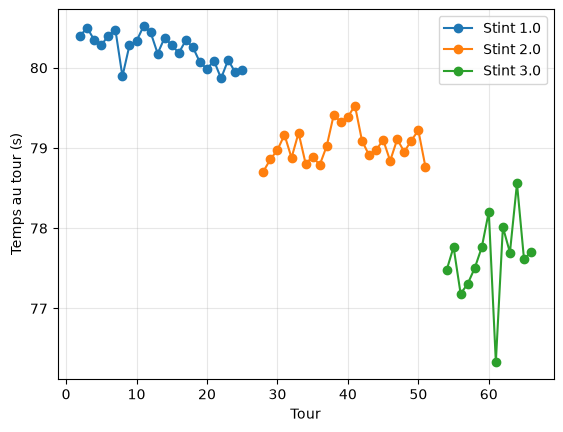

In [20]:
import fastf1 as ff1
import pandas as pd 
import matplotlib.pyplot as plt 

# Aller chercher les données Course + Pilotes
session = ff1.get_session(2023, "Spain", "R")
session.load()
print(session.event["EventName"], session.event["EventDate"])
laps = session.laps

def clean_laps(laps, driver):
    df = laps[laps["Driver"] == driver].copy()  # On choisit le pilote 
    df = df[df["TrackStatus"] == "1"]   # On prend les données uniquement sous drapeau vert 
    df = df[df["PitInTime"].isna() & df["PitOutTime"].isna()]   # On retire les tours où l'on rentre au stand (ralentit en fin de tour) et les tours où l'on sort des stand (pneus froids + traverser pit-lane)
    df = df[df["LapNumber"] > 1].copy()  # On retire le premier tour (grille, premier virage, chaos -> non représentatif)
    df["LapTimeSec"] = df["LapTime"].dt.total_seconds() # Conversion du temps en sec
    df = df.dropna(subset=["LapTimeSec"])   # Certains tours n'ont pas de temps enregistré 
    cols = ["LapNumber", "LapTimeSec", "Stint", "Compound", "TyreLife"] # On ne garde que les info utiles 
    return df[cols].reset_index(drop=True)

ver = clean_laps(laps, "VER")

for stint, g in ver.groupby("Stint"):
    plt.plot(g["LapNumber"], g["LapTimeSec"], "o-", label=f"Stint {stint}")
plt.xlabel("Tour")
plt.ylabel("Temps au tour (s)")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()




In [21]:
ver.groupby("Stint")["Compound"].unique()

Stint
1.0    [MEDIUM]
2.0      [HARD]
3.0      [SOFT]
Name: Compound, dtype: object

In [23]:
# Construction de la matrice

import numpy as np

N = 66
y = ver["LapTimeSec"].values
const = np.ones(len(ver))
fuel = N - ver["LapNumber"].values
hard = (ver["Compound"] == "HARD").astype(float).values
soft = (ver["Compound"] == "SOFT").astype(float).values
age = ver["TyreLife"].values
X = np.column_stack([const, fuel, hard, soft, age])
print(X.shape)
print(X[:5])

(61, 5)
[[ 1. 64.  0.  0.  2.]
 [ 1. 63.  0.  0.  3.]
 [ 1. 62.  0.  0.  4.]
 [ 1. 61.  0.  0.  5.]
 [ 1. 60.  0.  0.  6.]]
